# MA 310 Project: Parameter-Efficient Fine-Tuning with LoRA on DINOv2
### Low-Rank Adaptation vs Full Fine-Tuning on Oxford-IIIT Pet Dataset

In [ ]:
!pip install evaluate peft transformers datasets torch torchvision scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


## Imports & Configuration

In [ ]:
import torch
import evaluate
import numpy as np
import time
import gc
import random
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any
from datasets import load_dataset
from torchvision.transforms import Compose, Normalize, Resize, ToTensor, CenterCrop
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model
from sklearn.metrics import confusion_matrix

# ==========================================
# Configuration
# ==========================================
MODEL_CHECKPOINT = "facebook/dinov2-small"  # Vision Transformer, self-supervised
DATASET_NAME     = "visual-layer/oxford-iiit-pet-vl-enriched"
BATCH_SIZE       = 32
NUM_EPOCHS_LORA  = 5
NUM_EPOCHS_BASE  = 10
SEED             = 42

# LoRA rank ablation values
LORA_RANKS = [4, 8, 16]

def set_seed(seed: int):
    """Ensures reproducible results across runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Using device: cuda


## Data Loading & Preprocessing

In [ ]:
print("Loading dataset and processor...")
dataset = load_dataset(DATASET_NAME)

labels    = sorted(list(set(dataset["train"]["label_breed"])))
label2id  = {label: i for i, label in enumerate(labels)}
id2label  = {i: label for i, label in enumerate(labels)}
num_classes = len(labels)
print(f"Number of classes: {num_classes}")
print(f"Train size: {len(dataset['train'])}, Test size: {len(dataset['test'])}")

processor  = AutoImageProcessor.from_pretrained(MODEL_CHECKPOINT)
size       = processor.size["shortest_edge"]
image_mean = processor.image_mean
image_std  = processor.image_std

transforms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    Normalize(mean=image_mean, std=image_std)
])

def preprocess_images(examples):
    """Applies standard vision transformations to the image batch."""
    examples["pixel_values"] = [
        transforms(image.convert("RGB")) for image in examples["image"]
    ]
    return examples

train_ds = dataset["train"].with_transform(preprocess_images)
test_ds  = dataset["test"].with_transform(preprocess_images)

def collate_fn(examples):
    """Batches pixel values and maps string labels to integer IDs."""
    pixel_values  = torch.stack([example["pixel_values"] for example in examples])
    labels_tensor = torch.tensor([label2id[example["label_breed"]] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels_tensor}

Loading dataset and processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/149M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/133M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3680 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3669 [00:00<?, ? examples/s]

Number of classes: 37
Train size: 3680, Test size: 3669


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


## Metrics

In [ ]:
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """Calculates accuracy during the evaluation phase."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

## LoRA Experiment

In [ ]:
def run_lora_experiment(rank: int = 16) -> Dict[str, Any]:
    """
    Runs LoRA fine-tuning on DINOv2-small.

    LoRA injects trainable low-rank matrices A and B into the query and value
    projection layers of every Transformer block.
    All backbone weights are frozen; only A, B, and the classifier head are trained.

    B is initialised to zero, A is initialised with random Gaussian (N(0, sigma^2)).
    This means delta_W = B @ A = 0 at the start of training, so the model starts
    from exactly the pre-trained weights — no disruption to the pre-trained features.

    A single learning rate is safe here because the backbone is frozen.
    Only the small LoRA matrices and the classifier head receive gradient updates.
    """
    print(f"\n{'='*55}")
    print(f"  Starting LoRA Experiment  (rank r={rank})")
    print(f"{'='*55}")

    torch.cuda.empty_cache()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    model = AutoModelForImageClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    # LoRA configuration
    # target_modules=["query", "value"]
    # lora_alpha=2*rank
    # modules_to_save=["classifier"]
    config = LoraConfig(
        r=rank,
        lora_alpha=2 * rank,
        target_modules=["query", "value"],
        lora_dropout=0.1,
        modules_to_save=["classifier"]
    )
    model = get_peft_model(model, config)
    model.print_trainable_parameters()

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params     = sum(p.numel() for p in model.parameters())

    args = TrainingArguments(
        output_dir=f"./dinov2-lora-r{rank}",
        remove_unused_columns=False,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=1e-3,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        num_train_epochs=NUM_EPOCHS_LORA,
        warmup_ratio=0.1,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        logging_steps=50,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
        data_collator=collate_fn,
    )

    print("Starting LoRA training...")
    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    max_memory_mb = 0
    if torch.cuda.is_available():
        max_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    eval_results = trainer.evaluate()

    return trainer, {
        "Mode": f"LoRA (r={rank})",
        "Accuracy": f"{eval_results['eval_accuracy']*100:.2f}%",
        "Train Time (s)": f"{train_time:.2f}",
        "Epochs": NUM_EPOCHS_LORA,
        "Peak VRAM (MB)": f"{max_memory_mb:.2f}" if max_memory_mb > 0 else "N/A (CPU)",
        "Trainable Params": f"{trainable_params:,}",
        "Total Params": f"{total_params:,}",
        "Trainable %": f"{100 * trainable_params / total_params:.2f}%"
    }

## Baseline Experiment (Full Fine-Tuning with Differential Learning Rates)

In full fine-tuning we have **two very different kinds of parameters**:

1. **The backbone** (all 22M DINOv2 weights) — these are already well-trained on ImageNet-scale data. If you push them with a large LR, you destroy the learned features (called *catastrophic forgetting*).
2. **The classifier head** — this was randomly initialised (because we changed the number of output classes). It knows nothing yet. It *needs* a large LR to learn in just a few epochs.

Idea is to give the backbone a small LR (`2e-5`) and the classifier a large LR (`1e-3`). PyTorch's `AdamW` supports this via parameter groups — each group can have its own LR.

In [ ]:
def run_baseline_experiment() -> Dict[str, Any]:
    """
    Runs full fine-tuning (baseline) on DINOv2-small.

    Uses differential learning rates via parameter groups:
      - Backbone (pre-trained) : LR = 2e-5  (small, to preserve learned features)
      - Classifier head (random init): LR = 1e-3  (large, to learn quickly)

    Also uses NUM_EPOCHS_BASE = 10 so the baseline has enough time to converge.
    This also produces a visible time difference vs LoRA.

    The training time will be longer than LoRA for two reasons:
      1. More epochs (10 vs 5)
      2. Gradient computation for all 22M parameters (LoRA only computes
         gradients for ~200K parameters in the low-rank matrices)
    """
    print(f"\n{'='*55}")
    print(f"  Starting Baseline Experiment (Full Fine-Tuning)")
    print(f"{'='*55}")

    torch.cuda.empty_cache()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    model = AutoModelForImageClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params     = sum(p.numel() for p in model.parameters())
    print(f"Trainable Parameters: {trainable_params:,} / {total_params:,} (100.00%)")

    # -------------------------------------------------------
    # DIFFERENTIAL LEARNING RATES
    # Two parameter groups — backbone gets small LR,
    # classifier head gets large LR.
    # -------------------------------------------------------
    backbone_params    = list(model.dinov2.parameters())
    classifier_params  = list(model.classifier.parameters())

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params,   "lr": 2e-5},
            {"params": classifier_params, "lr": 1e-3},
        ],
        weight_decay=0.01
    )


    args = TrainingArguments(
        output_dir="./dinov2-baseline",
        remove_unused_columns=False,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        num_train_epochs=NUM_EPOCHS_BASE,
        warmup_ratio=0.1,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        logging_steps=50,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
        data_collator=collate_fn,
        optimizers=(optimizer, None),
    )

    print("Starting baseline training...")
    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    max_memory_mb = 0
    if torch.cuda.is_available():
        max_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    eval_results = trainer.evaluate()

    return trainer, {
        "Mode": "Baseline (Full FT)",
        "Accuracy": f"{eval_results['eval_accuracy']*100:.2f}%",
        "Train Time (s)": f"{train_time:.2f}",
        "Epochs": NUM_EPOCHS_BASE,
        "Peak VRAM (MB)": f"{max_memory_mb:.2f}" if max_memory_mb > 0 else "N/A (CPU)",
        "Trainable Params": f"{trainable_params:,}",
        "Total Params": f"{total_params:,}",
        "Trainable %": "100.00%"
    }

## Run Main Experiments

In [ ]:
lora_trainer, lora_res   = run_lora_experiment(rank=16)
base_trainer, base_res   = run_baseline_experiment()

# Print comparison table
print("\n" + "="*75)
print(f"  RESULTS COMPARISON")
print("="*75)
print(f"{'Metric':<22} | {'Baseline (Full FT)':<25} | {'LoRA (r=16)':<20}")
print("-" * 75)
for key in ["Accuracy", "Train Time (s)", "Epochs", "Peak VRAM (MB)",
            "Trainable Params", "Total Params", "Trainable %"]:
    print(f"{key:<22} | {base_res[key]:<25} | {lora_res[key]:<20}")
print("="*75)


  Starting LoRA Experiment  (rank r=16)


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainable Parameters: 22,085,029 / 22,085,029 (100.00%)
Starting baseline training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.563781,0.440065,0.855819
2,0.296077,0.661575,0.828019
3,0.146613,0.353943,0.895339
4,0.068569,0.386957,0.903516
5,0.039870,0.419448,0.898610
6,0.015025,0.428875,0.908422
7,0.000675,0.307507,0.935405
8,0.000049,0.301519,0.938130
9,0.000019,0.300078,0.938675
10,0.000019,0.299949,0.937858



  RESULTS COMPARISON
Metric                 | Baseline (Full FT)        | LoRA (r=16)         
---------------------------------------------------------------------------
Accuracy               | 93.79%                    | 94.36%              
Train Time (s)         | 674.33                    | 332.78              
Epochs                 | 10                        | 5                   
Peak VRAM (MB)         | 2564.52                   | 1672.56             
Trainable Params       | 22,085,029                | 323,365             
Total Params           | 22,085,029                | 22,408,394          
Trainable %            | 100.00%                   | 1.44%               


## Rank Ablation Study

The LoRA paperclaims that a very low rank (r=2 or r=4) is sufficient
because weight updates during adaptation have a low intrinsic rank.
We verify this by training with r = 4, 8, 16 and comparing accuracy.

In [ ]:
ablation_results = []

for r in LORA_RANKS:
    _, res = run_lora_experiment(rank=r)
    ablation_results.append(res)
    print(f"  r={r:>2}  →  Accuracy: {res['Accuracy']}  |  Trainable: {res['Trainable Params']}")

print("\nAblation Summary:")
print(f"{'Rank':<8} | {'Accuracy':<12} | {'Trainable Params':<20} | {'Trainable %'}")
print("-" * 60)
for res in ablation_results:
    r_label = res['Mode'].split('r=')[1].rstrip(')')
    print(f"{r_label:<8} | {res['Accuracy']:<12} | {res['Trainable Params']:<20} | {res['Trainable %']}")


  Starting LoRA Experiment  (rank r=4)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 102,181 || all params: 22,187,210 || trainable%: 0.4605
Starting LoRA training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.349509,0.295819,0.905969
2,0.151988,0.245311,0.934860
3,0.030317,0.212294,0.945762
4,0.005154,0.206969,0.945489
5,0.003174,0.203006,0.946307


...

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 323,365 || all params: 22,408,394 || trainable%: 1.4431
Starting LoRA training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.356647,0.467760,0.846552
2,0.186497,0.321604,0.901881
3,0.049658,0.227504,0.935677
4,0.005446,0.215641,0.941673
5,0.002252,0.211696,0.944126


  r=16  →  Accuracy: 94.41%  |  Trainable: 323,365

Ablation Summary:
Rank     | Accuracy     | Trainable Params     | Trainable %
------------------------------------------------------------
4        | 94.63%       | 102,181              | 0.46%
8        | 94.60%       | 175,909              | 0.79%
16       | 94.41%       | 323,365              | 1.44%


## Rank-Deficiency Analysis (Paper Section 4.1)

The LoRA paper hypothesises that the update matrix delta_W = B @ A lies in a
low-rank subspace — i.e., most of the "learning signal" lives in just a few
singular directions. We verify this by computing the Singular Value Decomposition
of B @ A for each LoRA layer and plotting the singular value spectrum.

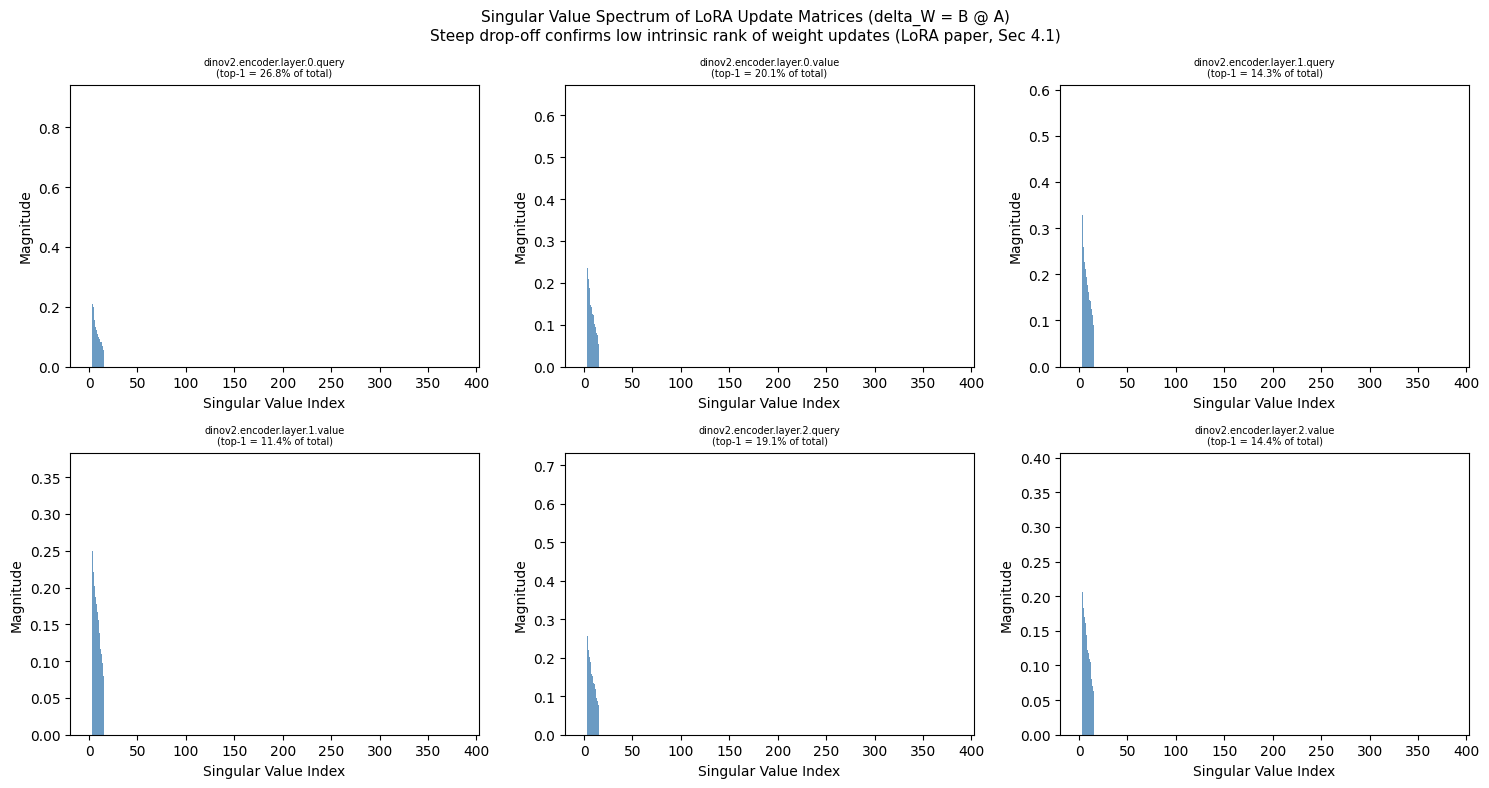

Analysed 24 LoRA layers total.


In [ ]:
def analyse_rank_deficiency(trainer):
    """
    For each LoRA layer, we compute delta_W = B @ A and its singular values.
    We plot the singular value spectrum to show that most mass is concentrated
    in the top few singular values (low effective rank).
    """
    model = trainer.model
    all_singular_values = []
    layer_names = []

    for name, module in model.named_modules():
        # PEFT names LoRA matrices as lora_A and lora_B inside the layer
        if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
            # lora_A and lora_B are ModuleDicts keyed by adapter name ('default')
            A = module.lora_A['default'].weight.data   # shape: (r, in_features)
            B = module.lora_B['default'].weight.data   # shape: (out_features, r)
            delta_W = B @ A                            # shape: (out_features, in_features)

            # SVD — we only need singular values, not full U and V
            singular_values = torch.linalg.svdvals(delta_W.float()).cpu().numpy()
            all_singular_values.append(singular_values)

            short_name = name.replace("base_model.model.", "").replace(".attention", "")
            layer_names.append(short_name)

    if not all_singular_values:
        print("No LoRA layers found in model. Run LoRA experiment first.")
        return

    # Plot singular value spectrum for first 6 layers
    n_plot = min(6, len(all_singular_values))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i in range(n_plot):
        sv = all_singular_values[i]
        axes[i].bar(range(len(sv)), sv, color='steelblue', alpha=0.8)
        axes[i].set_title(f"{layer_names[i]}", fontsize=8)
        axes[i].set_xlabel("Singular Value Index")
        axes[i].set_ylabel("Magnitude")
        # Mark how much mass is in top-1 singular value
        top1_pct = sv[0] / sv.sum() * 100
        axes[i].set_title(f"{layer_names[i]}\n(top-1 = {top1_pct:.1f}% of total)", fontsize=7)

    plt.suptitle("Singular Value Spectrum of LoRA Update Matrices (delta_W = B @ A)\n"
                 "Steep drop-off confirms low intrinsic rank of weight updates (LoRA paper, Sec 4.1)",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig("rank_deficiency_analysis.png", dpi=200)
    plt.show()
    print(f"Analysed {len(all_singular_values)} LoRA layers total.")

analyse_rank_deficiency(lora_trainer)

## Training Curves

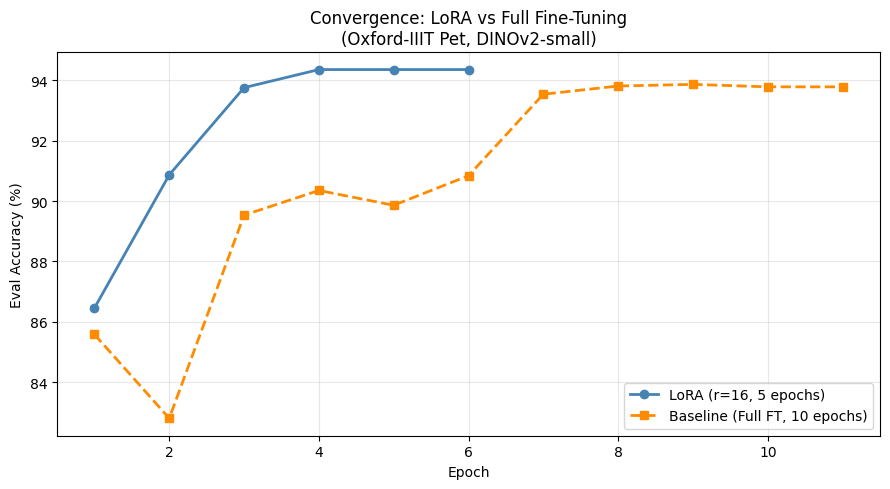

In [ ]:
def plot_training_curves(lora_trainer, base_trainer):
    """
    Plot per-epoch eval accuracy for LoRA vs Baseline.
    Visualises convergence speed — LoRA typically reaches high accuracy
    faster per epoch because the classifier head and LoRA matrices adapt quickly.
    """
    def extract_eval_accuracy(trainer):
        return [
            entry['eval_accuracy']
            for entry in trainer.state.log_history
            if 'eval_accuracy' in entry
        ]

    lora_acc = extract_eval_accuracy(lora_trainer)
    base_acc = extract_eval_accuracy(base_trainer)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(range(1, len(lora_acc) + 1), [a * 100 for a in lora_acc],
            'o-', label=f'LoRA (r=16, {NUM_EPOCHS_LORA} epochs)', color='steelblue', linewidth=2)
    ax.plot(range(1, len(base_acc) + 1), [a * 100 for a in base_acc],
            's--', label=f'Baseline (Full FT, {NUM_EPOCHS_BASE} epochs)', color='darkorange', linewidth=2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Eval Accuracy (%)")
    ax.set_title("Convergence: LoRA vs Full Fine-Tuning\n(Oxford-IIIT Pet, DINOv2-small)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=200)
    plt.show()

plot_training_curves(lora_trainer, base_trainer)

## Confusion Matrix

Generating Confusion Matrix for LoRA DINOv2...


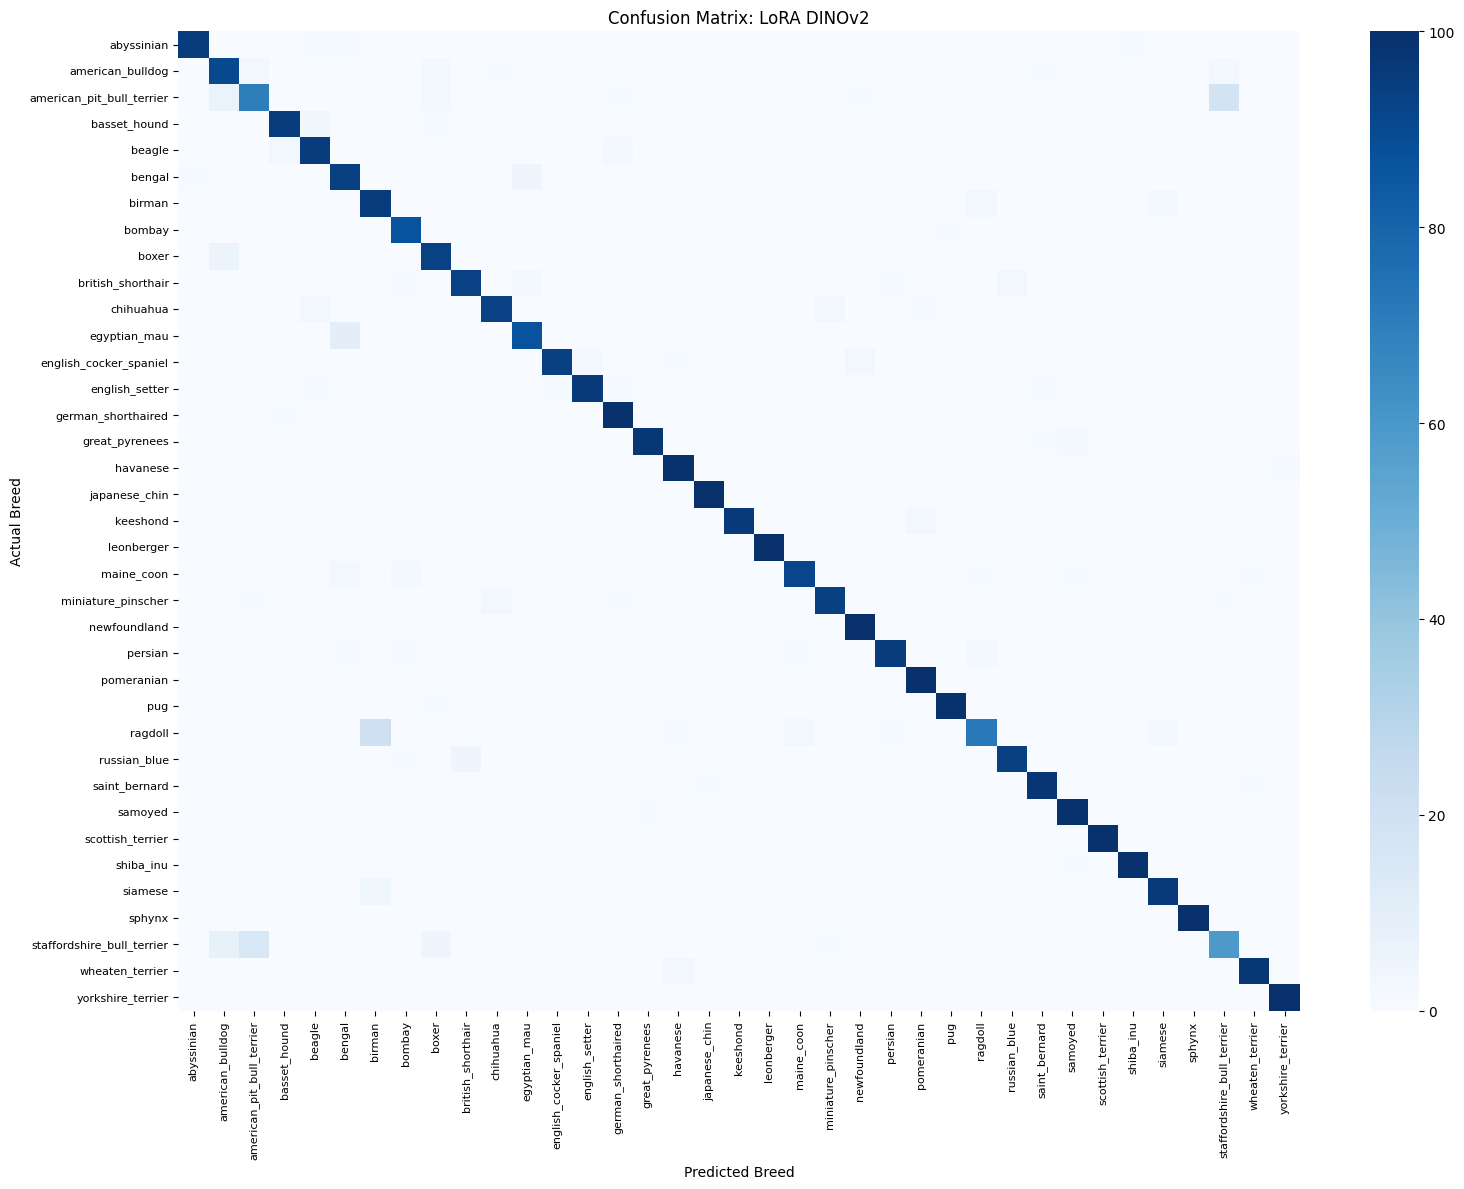

Generating Confusion Matrix for Baseline DINOv2...


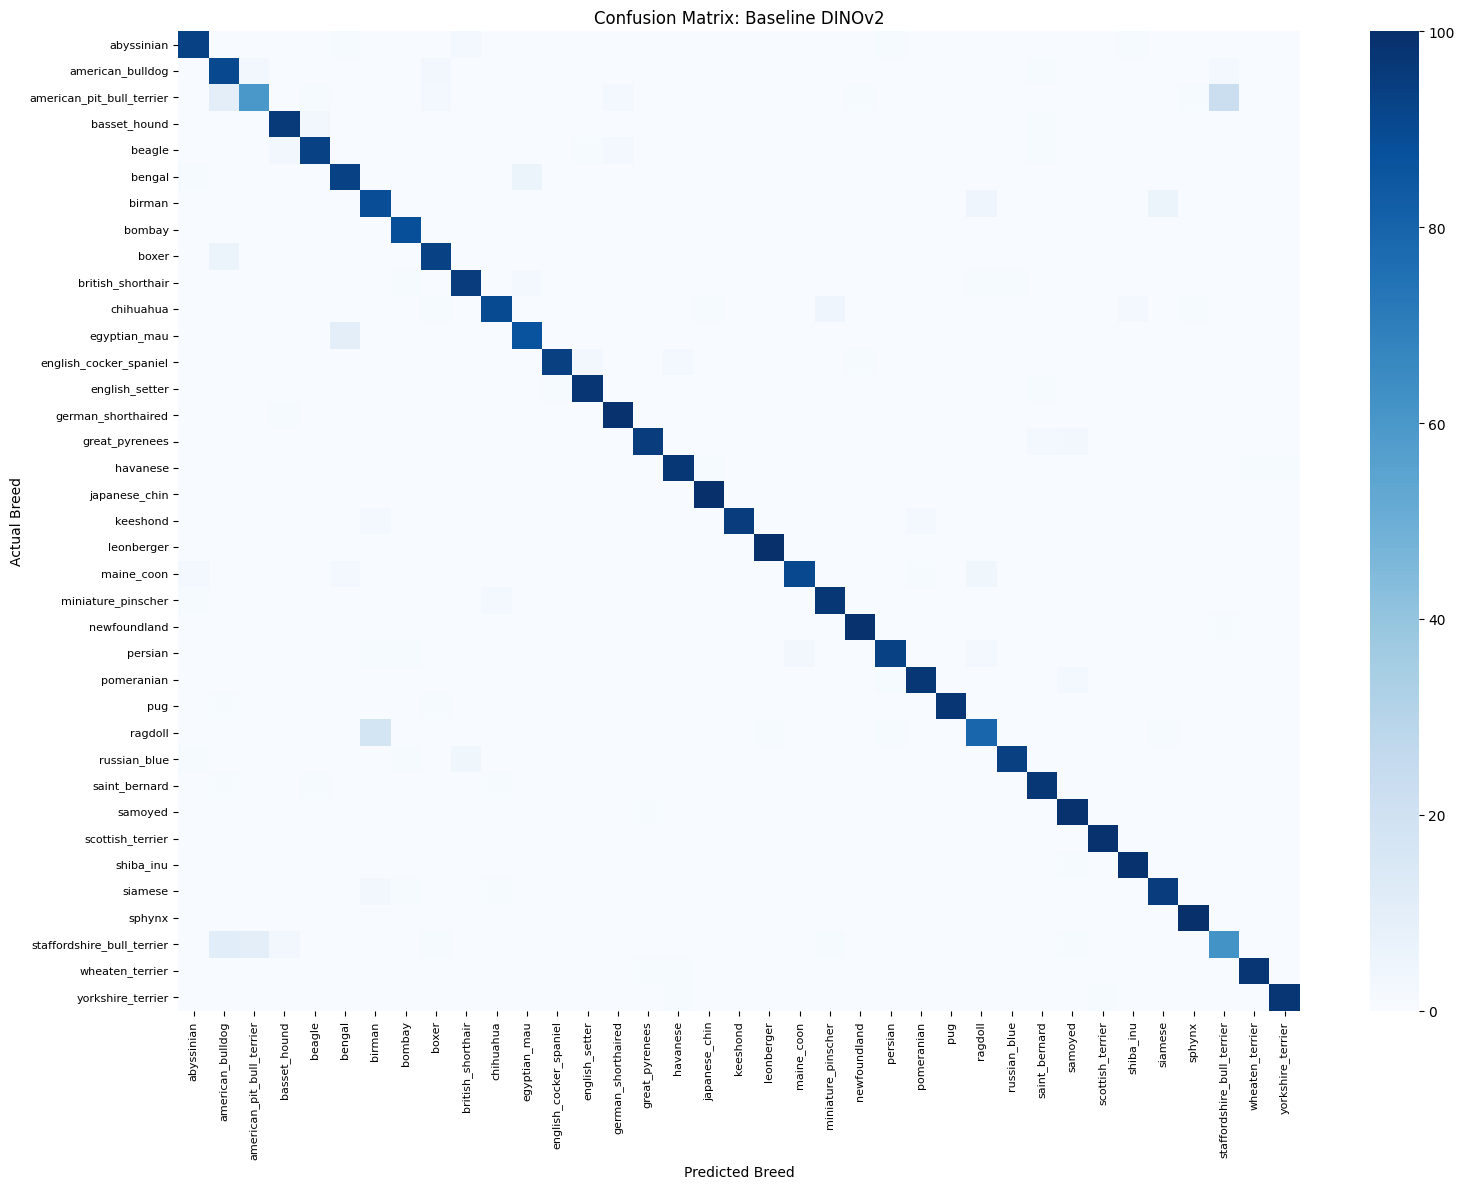

In [ ]:
def plot_confusion_matrix(trainer, dataset, title):
    print(f"Generating Confusion Matrix for {title}...")
    predictions = trainer.predict(dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=False, cmap="Blues", fmt="d",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted Breed")
    plt.ylabel("Actual Breed")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{title.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

plot_confusion_matrix(lora_trainer, test_ds, "LoRA DINOv2")
plot_confusion_matrix(base_trainer, test_ds, "Baseline DINOv2")

## Final Summary Table

In [ ]:
print("\n" + "="*80)
print("  FINAL SUMMARY")
print("="*80)
print(f"{'Metric':<22} | {'Baseline (Full FT)':<25} | {'LoRA (r=16)'}")
print("-" * 80)
for key in ["Accuracy", "Train Time (s)", "Epochs", "Peak VRAM (MB)",
            "Trainable Params", "Total Params", "Trainable %"]:
    print(f"{key:<22} | {base_res.get(key, 'N/A'):<25} | {lora_res.get(key, 'N/A')}")
print("="*80)

print("\nRank Ablation (LoRA):")
print(f"{'Rank':<8} | {'Accuracy':<12} | {'Trainable Params':<20} | Trainable %")
print("-" * 60)
for res in ablation_results:
    r_label = res['Mode'].split('r=')[1].rstrip(')')
    print(f"{r_label:<8} | {res['Accuracy']:<12} | {res['Trainable Params']:<20} | {res['Trainable %']}")


  FINAL SUMMARY
Metric                 | Baseline (Full FT)        | LoRA (r=16)
--------------------------------------------------------------------------------
Accuracy               | 93.79%                    | 94.36%
Train Time (s)         | 674.33                    | 332.78
Epochs                 | 10                        | 5
Peak VRAM (MB)         | 2564.52                   | 1672.56
Trainable Params       | 22,085,029                | 323,365
Total Params           | 22,085,029                | 22,408,394
Trainable %            | 100.00%                   | 1.44%

Rank Ablation (LoRA):
Rank     | Accuracy     | Trainable Params     | Trainable %
------------------------------------------------------------
4        | 94.63%       | 102,181              | 0.46%
8        | 94.60%       | 175,909              | 0.79%
16       | 94.41%       | 323,365              | 1.44%
